<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 6.3
# *KNN classification Lab*

**In this lab, we will:**
- Practice KNN classification on a dataset of breast cancer.
- Predict the `diagnoosis` of a patient from predictor variables of your choice.

### 1. Load Data

Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image. n the 3-dimensional space is that described in: [K. P. Bennett and O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34].

This database is also available through the UW CS ftp server: ftp ftp.cs.wisc.edu cd math-prog/cpo-dataset/machine-learn/WDBC/

Also can be found on UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29

Attribute Information:

1) ID number 2) Diagnosis (M = malignant, B = benign) 3-32)

Ten real-valued features are computed for each cell nucleus:

a) radius (mean of distances from center to points on the perimeter) b) texture (standard deviation of gray-scale values) c) perimeter d) area e) smoothness (local variation in radius lengths) f) compactness (perimeter^2 / area - 1.0) g) concavity (severity of concave portions of the contour) h) concave points (number of concave portions of the contour) i) symmetry j) fractal dimension ("coastline approximation" - 1)

The mean, standard error and "worst" or largest (mean of the three largest values) of these features were computed for each image, resulting in 30 features. For instance, field 3 is Mean Radius, field 13 is Radius SE, field 23 is Worst Radius.

All feature values are recoded with four significant digits.

Missing attribute values: none

Class distribution: 357 benign, 212 malignant

In [1]:
import numpy as np
import pandas as pd

# The clustering muscle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# The visualization duo
import matplotlib.pyplot as plt
import seaborn as snsRIES

In [3]:
breast_cancer_csv = 'breast-cancer-wisconsin-data.csv'
df = pd.read_csv(breast_cancer_csv)

### 2. EDA

Explore dataset. Clean data. Find correlation.

In [4]:
df.head

<bound method NDFrame.head of            id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0  

In [7]:
df_cleaned = df.drop(columns=['Unnamed: 32', 'id'], errors='ignore')

# 3. Encode the categorical 'diagnosis' column
# Malignant (M) -> 1, Benign (B) -> 0
df_cleaned['diagnosis'] = df_cleaned['diagnosis'].map({'M': 1, 'B': 0})

# 4. Save the result for clustering or modeling
df_cleaned.to_csv('breast_cancer_cleaned.csv', index=False)

print("Dataset cleaned successfully!")
print(f"Remaining columns: {len(df_cleaned.columns)}")

Dataset cleaned successfully!
Remaining columns: 31


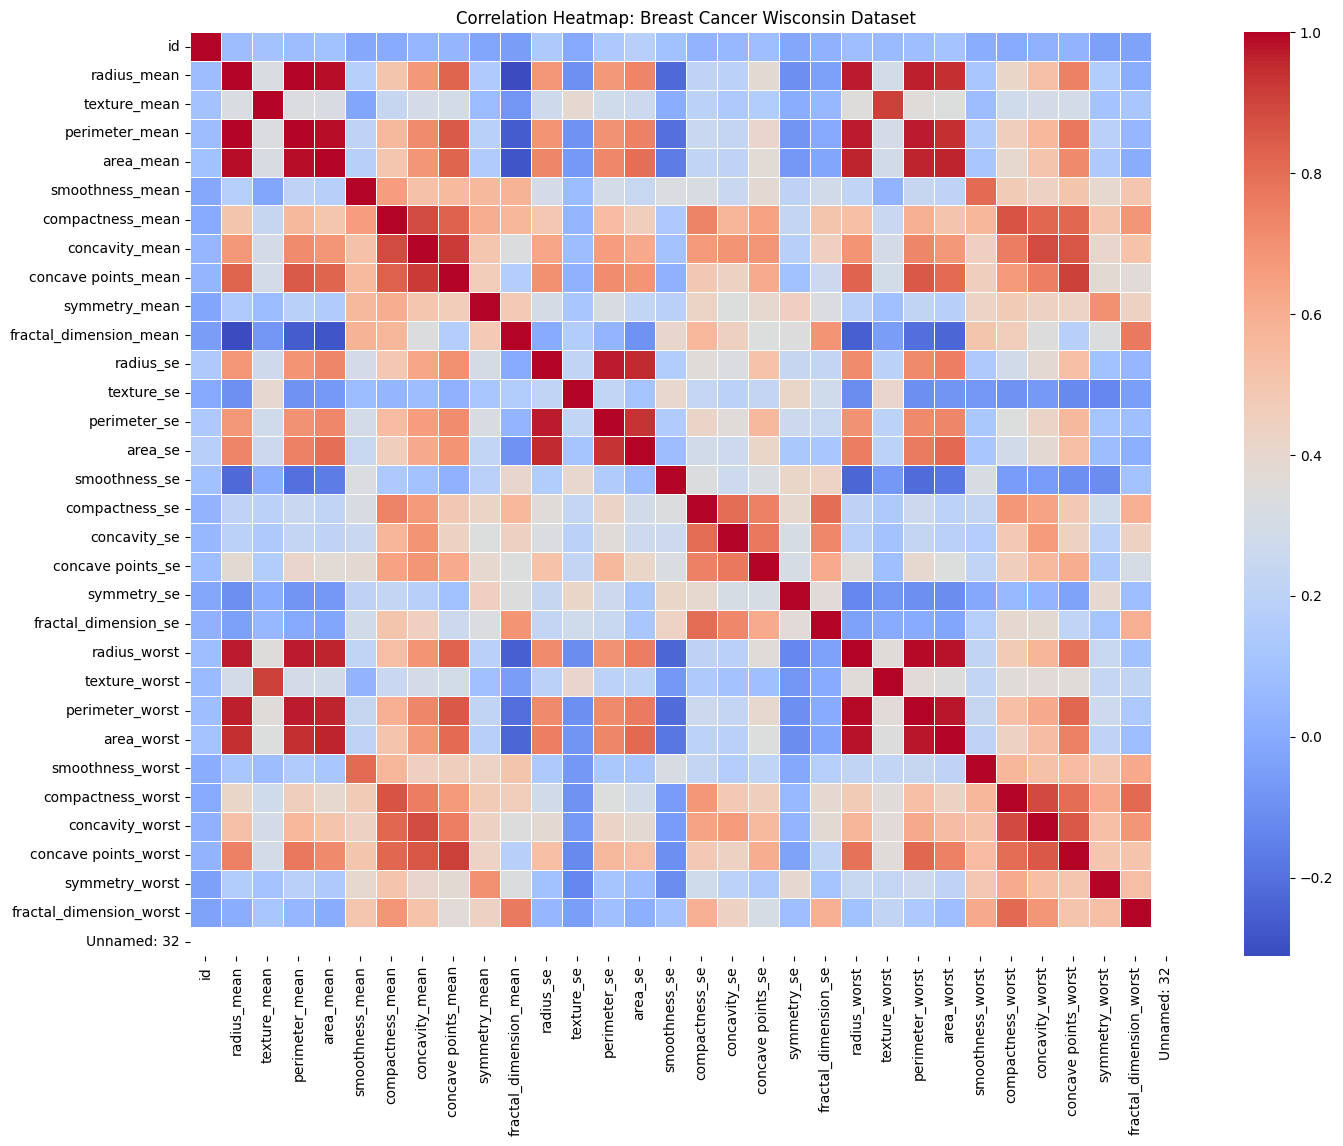

In [10]:
import seaborn as sns

X = df.drop(columns=['diagnosis'])

corr_matrix = X.corr()

# 3. Create the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=False, # Set to True to see the exact numbers
            cmap='coolwarm', 
            linewidths=0.5)

plt.title('Correlation Heatmap: Breast Cancer Wisconsin Dataset')
plt.show()

### 3. Set up the `diagnosis` variable as your target. How many classes are there?

In [11]:
df_cleaned = df.drop(columns=['Unnamed: 32', 'id'], errors='ignore')

# 3. Identify Target Classes
target_col = 'diagnosis'
unique_classes = df_cleaned[target_col].unique()
num_classes = df_cleaned[target_col].nunique()
class_distribution = df_cleaned[target_col].value_counts()

# 4. Encoding the Target
# Map 'M' (Malignant) to 1 and 'B' (Benign) to 0 to make it numeric
df_cleaned[target_col] = df_cleaned[target_col].map({'M': 1, 'B': 0})

# --- Display Results ---
print(f"Target Column: {target_col}")
print(f"Classes Found: {unique_classes}")
print(f"Total Number of Classes: {num_classes}")
print("\nClass Distribution:")
print(class_distribution)

print("\nFirst 5 rows of Cleaned Dataset:")
print(df_cleaned.head())

Target Column: diagnosis
Classes Found: <ArrowStringArray>
['M', 'B']
Length: 2, dtype: str
Total Number of Classes: 2

Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

First 5 rows of Cleaned Dataset:
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390       

### 4. What is the baseline accuracy?

In [12]:
df = pd.read_csv('breast-cancer-wisconsin-data.csv')

# 2. Get the distribution of the target classes
counts = df['diagnosis'].value_counts()

# 3. Calculate Baseline Accuracy
# (Count of Majority Class) / (Total Number of Samples)
majority_class_count = counts.max()
total_samples = len(df)
baseline_accuracy = majority_class_count / total_samples

print(f"Majority Class Count: {majority_class_count}")
print(f"Total Samples: {total_samples}")
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")





Majority Class Count: 357
Total Samples: 569
Baseline Accuracy: 0.6274


### 5. Choose features to be your predictor variables and set up your X.

In [13]:
df = pd.read_csv('breast-cancer-wisconsin-data.csv')

# 2. Define the predictor variables (X)
# We drop 'id', 'diagnosis', and the empty 'Unnamed: 32' column
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')

# 3. Define the target variable (y)
y = df['diagnosis']

# Verify the setup
print(f"Number of predictor variables (features): {X.shape[1]}")
print(f"Number of observations: {X.shape[0]}")

Number of predictor variables (features): 30
Number of observations: 569


### 6. Fit a `KNeighborsClassifier` with 1 neighbor using the target and predictors.

In [15]:
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv('breast-cancer-wisconsin-data.csv')
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis']

# 2. Initialize the model with k=1
knn = KNeighborsClassifier(n_neighbors=1)

# 3. Fit the model to your predictors (X) and target (y)
knn.fit(X, y)

print("KNeighborsClassifier is now fitted.")

KNeighborsClassifier is now fitted.


### 7. Evaluate the accuracy of your model.
- Is it better than baseline?
- Is it legitimate?

In [16]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Load the dataset
df = pd.read_csv('breast-cancer-wisconsin-data.csv')

# 2. Set up Predictors (X) and Target (y)
# We drop 'id', the target 'diagnosis', and the empty 'Unnamed: 32' column
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis']

# 3. Calculate Baseline Accuracy (for comparison)
majority_class_count = y.value_counts().max()
baseline_accuracy = majority_class_count / len(y)

# 4. Initialize and Fit the KNN Model (k=1)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)

# 5. Evaluate Accuracy
# We predict on the same data used for training
y_pred = knn.predict(X)
model_accuracy = accuracy_score(y, y_pred)

# --- Display Results ---
print(f"Baseline Accuracy (Guessing 'B' every time): {baseline_accuracy:.4f}")
print(f"Model Accuracy (k=1): {model_accuracy:.4f}")

if model_accuracy > baseline_accuracy:
    print("\nSuccess: The model is performing better than the baseline on the training data.")

Baseline Accuracy (Guessing 'B' every time): 0.6274
Model Accuracy (k=1): 1.0000

Success: The model is performing better than the baseline on the training data.


### 8. Create a 80-20 train-test-split of your target and predictors. Refit the KNN and assess the accuracy.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Prepare Data
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis']

# 2. Perform 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Scaling (Crucial for KNN)
# Since KNN uses distance, we must ensure all features are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Refit the KNN Classifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_scaled, y_train)

# 5. Assess the Accuracy
train_acc = knn.score(X_train_scaled, y_train)
test_acc = knn.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.9386


### 9. Evaluate the test accuracy of a KNN where K == number of rows in the training data.

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Load and Clean Data
df = pd.read_csv('breast-cancer-wisconsin-data.csv')
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis']

# 2. 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Scaling (Important for KNN distance calculations)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Set K equal to the total number of rows in the training data
K_value = len(X_train)

# 5. Fit the KNN model
knn_max = KNeighborsClassifier(n_neighbors=K_value)
knn_max.fit(X_train_scaled, y_train)

# 6. Evaluate Accuracy
test_accuracy = knn_max.score(X_test_scaled, y_test)
train_majority_freq = y_train.value_counts(normalize=True).max()

print(f"Number of Neighbors (K): {K_value}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Majority Class Frequency in Training: {train_majority_freq:.4f}")

Number of Neighbors (K): 455
Test Accuracy: 0.6228
Majority Class Frequency in Training: 0.6286


### 10. Fit the KNN at values of K from 1 to the number of rows in the training data.
- Store the test accuracy in a list.
- Plot the test accuracy vs. the number of neighbors.

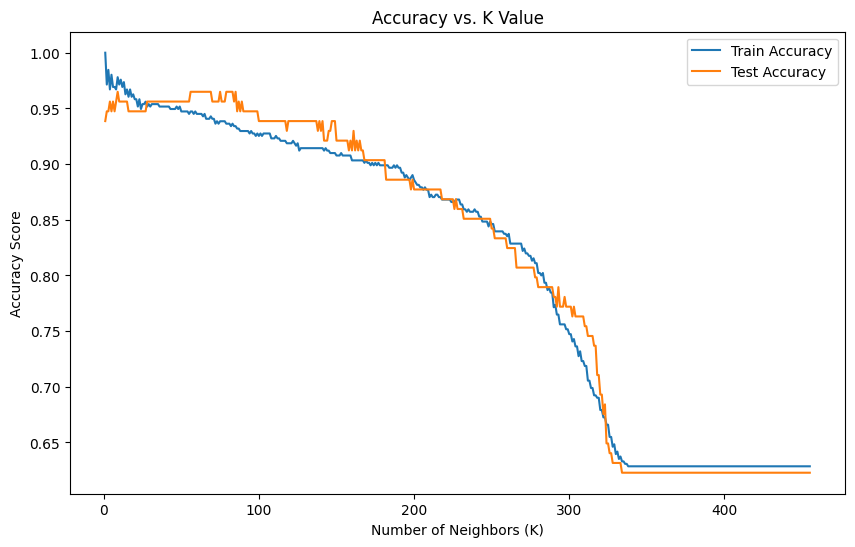

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Scale Data (Essential for valid distance comparisons)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Iterate through K values
train_scores = []
test_scores = []
k_range = range(1, len(X_train) + 1)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_scores, label='Train Accuracy')
plt.plot(k_range, test_scores, label='Test Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy Score')
plt.title('Accuracy vs. K Value')
plt.legend()
plt.show()

### 11. Fit KNN across different values of K and plot the mean cross-validated accuracy with 5 folds.


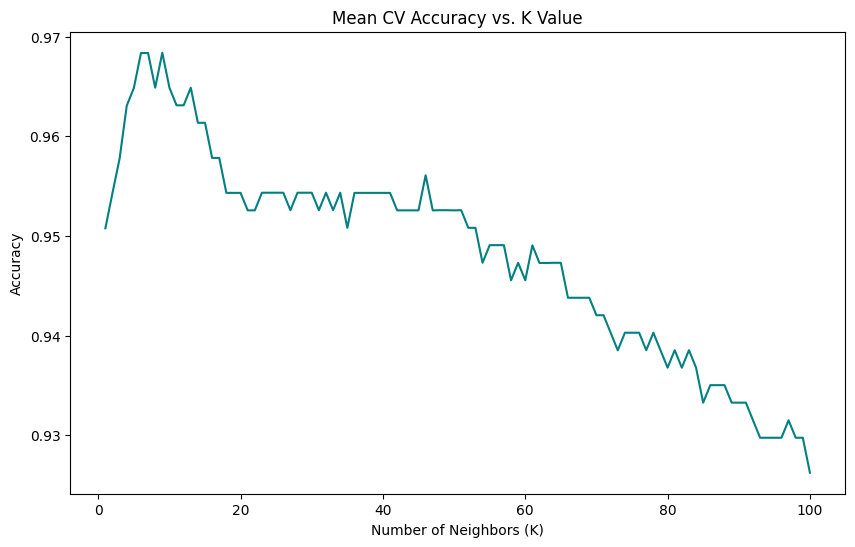

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis'].map({'M': 1, 'B': 0})

# 2. Scaling (Required for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Iterate through K values with 5-Fold Cross-Validation
k_values = range(1, 101)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Calculate the average accuracy across 5 different splits
    scores = cross_val_score(knn, X_scaled, y, cv=5)
    cv_scores.append(scores.mean())

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, color='teal')
plt.title('Mean CV Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.show()

### 12. Standardize the predictor matrix and cross-validate across the different K.
- Plot the standardized mean cross-validated accuracy against the unstandardized. Which is better?
- Why?

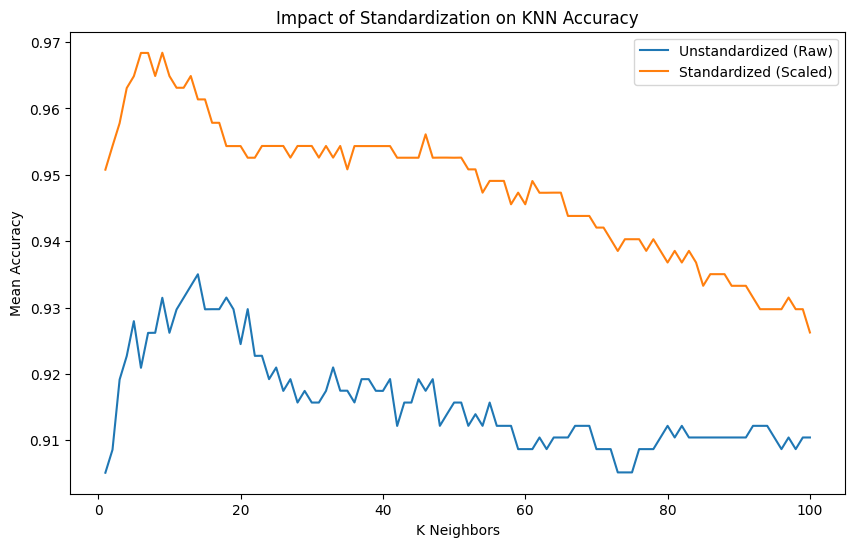

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis']
X_scaled = StandardScaler().fit_transform(X)

# 2. Cross-Validate both versions
k_range = range(1, 101)
raw_scores = []
scaled_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    raw_scores.append(cross_val_score(knn, X, y, cv=5).mean())
    scaled_scores.append(cross_val_score(knn, X_scaled, y, cv=5).mean())

# 3. Plot Comparison
plt.figure(figsize=(10, 6))
plt.plot(k_range, raw_scores, label='Unstandardized (Raw)')
plt.plot(k_range, scaled_scores, label='Standardized (Scaled)')
plt.xlabel('K Neighbors')
plt.ylabel('Mean Accuracy')
plt.title('Impact of Standardization on KNN Accuracy')
plt.legend()
plt.show()

In [ ]:
# ANSWER
# plot test accuracy by number of neighbors:

**References**

[Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data/downloads/breast-cancer-wisconsin-data.zip/2)



---



---



> > > > > > > > > © 2026 Institute of Data


---



---



